In [1]:
# Import necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import coordinates as coords
from astropy.table import Table
from astropy.cosmology import LambdaCDM
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Set cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

import matplotlib.pyplot as plt

# Matplotlib configuration
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,           
    'ytick.right': True,         
    'xtick.minor.visible': True, 
    'ytick.minor.visible': True, 
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Pandas configuration
pd.set_option('display.max_columns', None)

# Paths configuration
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']
MAINPATH =  "/Users/jonginpark/sohnix/Research_Archive/2026/Park2026b-MACH-SMF"

%config InlineBackend.figure_format = 'retina'

In [2]:
# Load MACH master catalog
mach_path = f"{MAINPATH}/DATA/MACH_MASS/MACH_DR18_3R200_mastercat.csv"
mach_data = pd.read_csv(mach_path)

# Correct cmodel magnitudes for extinction
for band in ("g", "r"):
    mach_data[f"cmodelMag_{band}_0"] = (
        mach_data[f"cmodelMag_{band}"] - mach_data[f"extinction_{band}"]
    )

# Load HeCS VAC catalog
hecs_vac_path = f"{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv"
hecs_vac_data = pd.read_csv(hecs_vac_path)

df = mach_data.copy()

# Construct Mock_z: use Z_TOT_Z, but if Z_TOT_Z == -99, use cluster mean z from hecs_vac_data (by CLID)
df["Mock_z"] = df["Z_TOT_Z"]

# Find rows with Z_TOT_Z == -99
mask_noz = (df["Z_TOT_Z"] == -99)

# For those rows, replace with matching cluster z from hecs_vac_data
if "CLID" in df.columns and "CLID" in hecs_vac_data.columns:
    # Construct cluster z dictionary from hecs_vac_data
    clid_to_z = hecs_vac_data.set_index("CLID")["Z"].to_dict()
    # Fill Mock_z for those without z
    df.loc[mask_noz, "Mock_z"] = df.loc[mask_noz, "CLID"].map(clid_to_z)

# Compute absolute r-band magnitude using Mock_z
lum_dist_pc = cosmo.luminosity_distance(df["Mock_z"]).to("pc").value
df["AbsMag_r"] = df["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_69801/881514430.py:32: RuntimeWarning: divide by zero encountered in log10
  df["AbsMag_r"] = df["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_69801/881514430.py:32: RuntimeWarning: invalid value encountered in log10
  df["AbsMag_r"] = df["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck15 as cosmo

# =============================================================
# 1. Clean input dataframe
# =============================================================

# Drop unphysical redshifts (keep -99 as "no spec-z" flag)
df = df[~((df["Z_TOT_Z"] <= 0) & (df["Z_TOT_Z"] != -99))]

# Drop rows with missing photometry
df = df[(df["cmodelMag_r"] != -9999) & (df["cmodelMag_g"] != -9999)].copy()

df_correction = df.copy()

# =============================================================
# 2. Assign best-available redshift
#    spec-z if available, otherwise fall back to cluster z
# =============================================================
def get_best_redshift(row):
    if row["Z_TOT_Z"] != -99:
        return row["Z_TOT_Z"]
    match = hecs_vac_data.loc[hecs_vac_data["CLID"] == row["CLID"], "Z"]
    return match.iloc[0] if not match.empty else np.nan

df_correction["Z_corrected"] = df_correction.apply(get_best_redshift, axis=1)

# =============================================================
# 3. Derived photometric quantities
# =============================================================

# Absolute r-band magnitude
dist_pc = cosmo.luminosity_distance(df_correction["Z_corrected"]).to("pc").value
df_correction["AbsMag_r"] = df_correction["cmodelMag_r_0"] - 5 * (np.log10(dist_pc) - 1)

# Extinction-corrected (g - r) colour
df_correction["(g-r)"] = df_correction["cmodelMag_g_0"] - df_correction["cmodelMag_r_0"]

# =============================================================
# 4. Bin galaxies in 3D: Mr × (g-r) × Rcl/R200
# =============================================================

abs_mag_r_bins = np.arange(-30, 10, 1.00)
gr_bins        = np.arange(-6.5, 15.25, 0.25)
rcl_r200_bins  = np.arange(0, 3.2, 0.20)

df_correction["Mr_bin"]    = pd.cut(df_correction["AbsMag_r"],  bins=abs_mag_r_bins)
df_correction["color_bin"] = pd.cut(df_correction["(g-r)"],     bins=gr_bins)
df_correction["Rcl_bin"]   = pd.cut(df_correction["Rcl/R200"],  bins=rcl_r200_bins)

# =============================================================
# 5. Compute completeness fractions
# =============================================================

def calculate_f_spec(df_group):
    """Fraction of galaxies with a spectroscopic redshift (per Mr_bin)."""
    if len(df_group) == 0:
        return 0.0
    return (df_group["Z_TOT_Z"] != -99.0).sum() / len(df_group)

def calculate_f_mem(df_group):
    """Fraction of spec-z galaxies that are cluster members (per 3D bin)."""
    n_spec = (df_group["Z_TOT_Z"] != -99.0).sum()
    if n_spec == 0:
        return 0.0
    n_mem = ((df_group["Z_TOT_Z"] != -99.0) & (df_group["MEMBER"] == "Y")).sum()
    return n_mem / n_spec

f_spec_map = df_correction.groupby("Mr_bin").apply(calculate_f_spec)
f_mem_map  = df_correction.groupby(["Mr_bin", "color_bin", "Rcl_bin"]).apply(calculate_f_mem)

# =============================================================
# 6. Build summary table and save
# =============================================================

f_mem_df = f_mem_map.reset_index().rename(columns={0: "f_mem"})
f_mem_df["f_spec"] = f_mem_df["Mr_bin"].map(f_spec_map)

f_mem_df.to_csv("MACH_SMF_fspec_fmem_bin.csv", index=False)

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_69801/166872767.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  f_spec_map = df_correction.groupby("Mr_bin").apply(calculate_f_spec)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_69801/166872767.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  f_spec_map = df_correction.groupby("Mr_bin").apply(calculate_f_spec)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_69801/166872767.py:72: FutureWarning: The default of observe

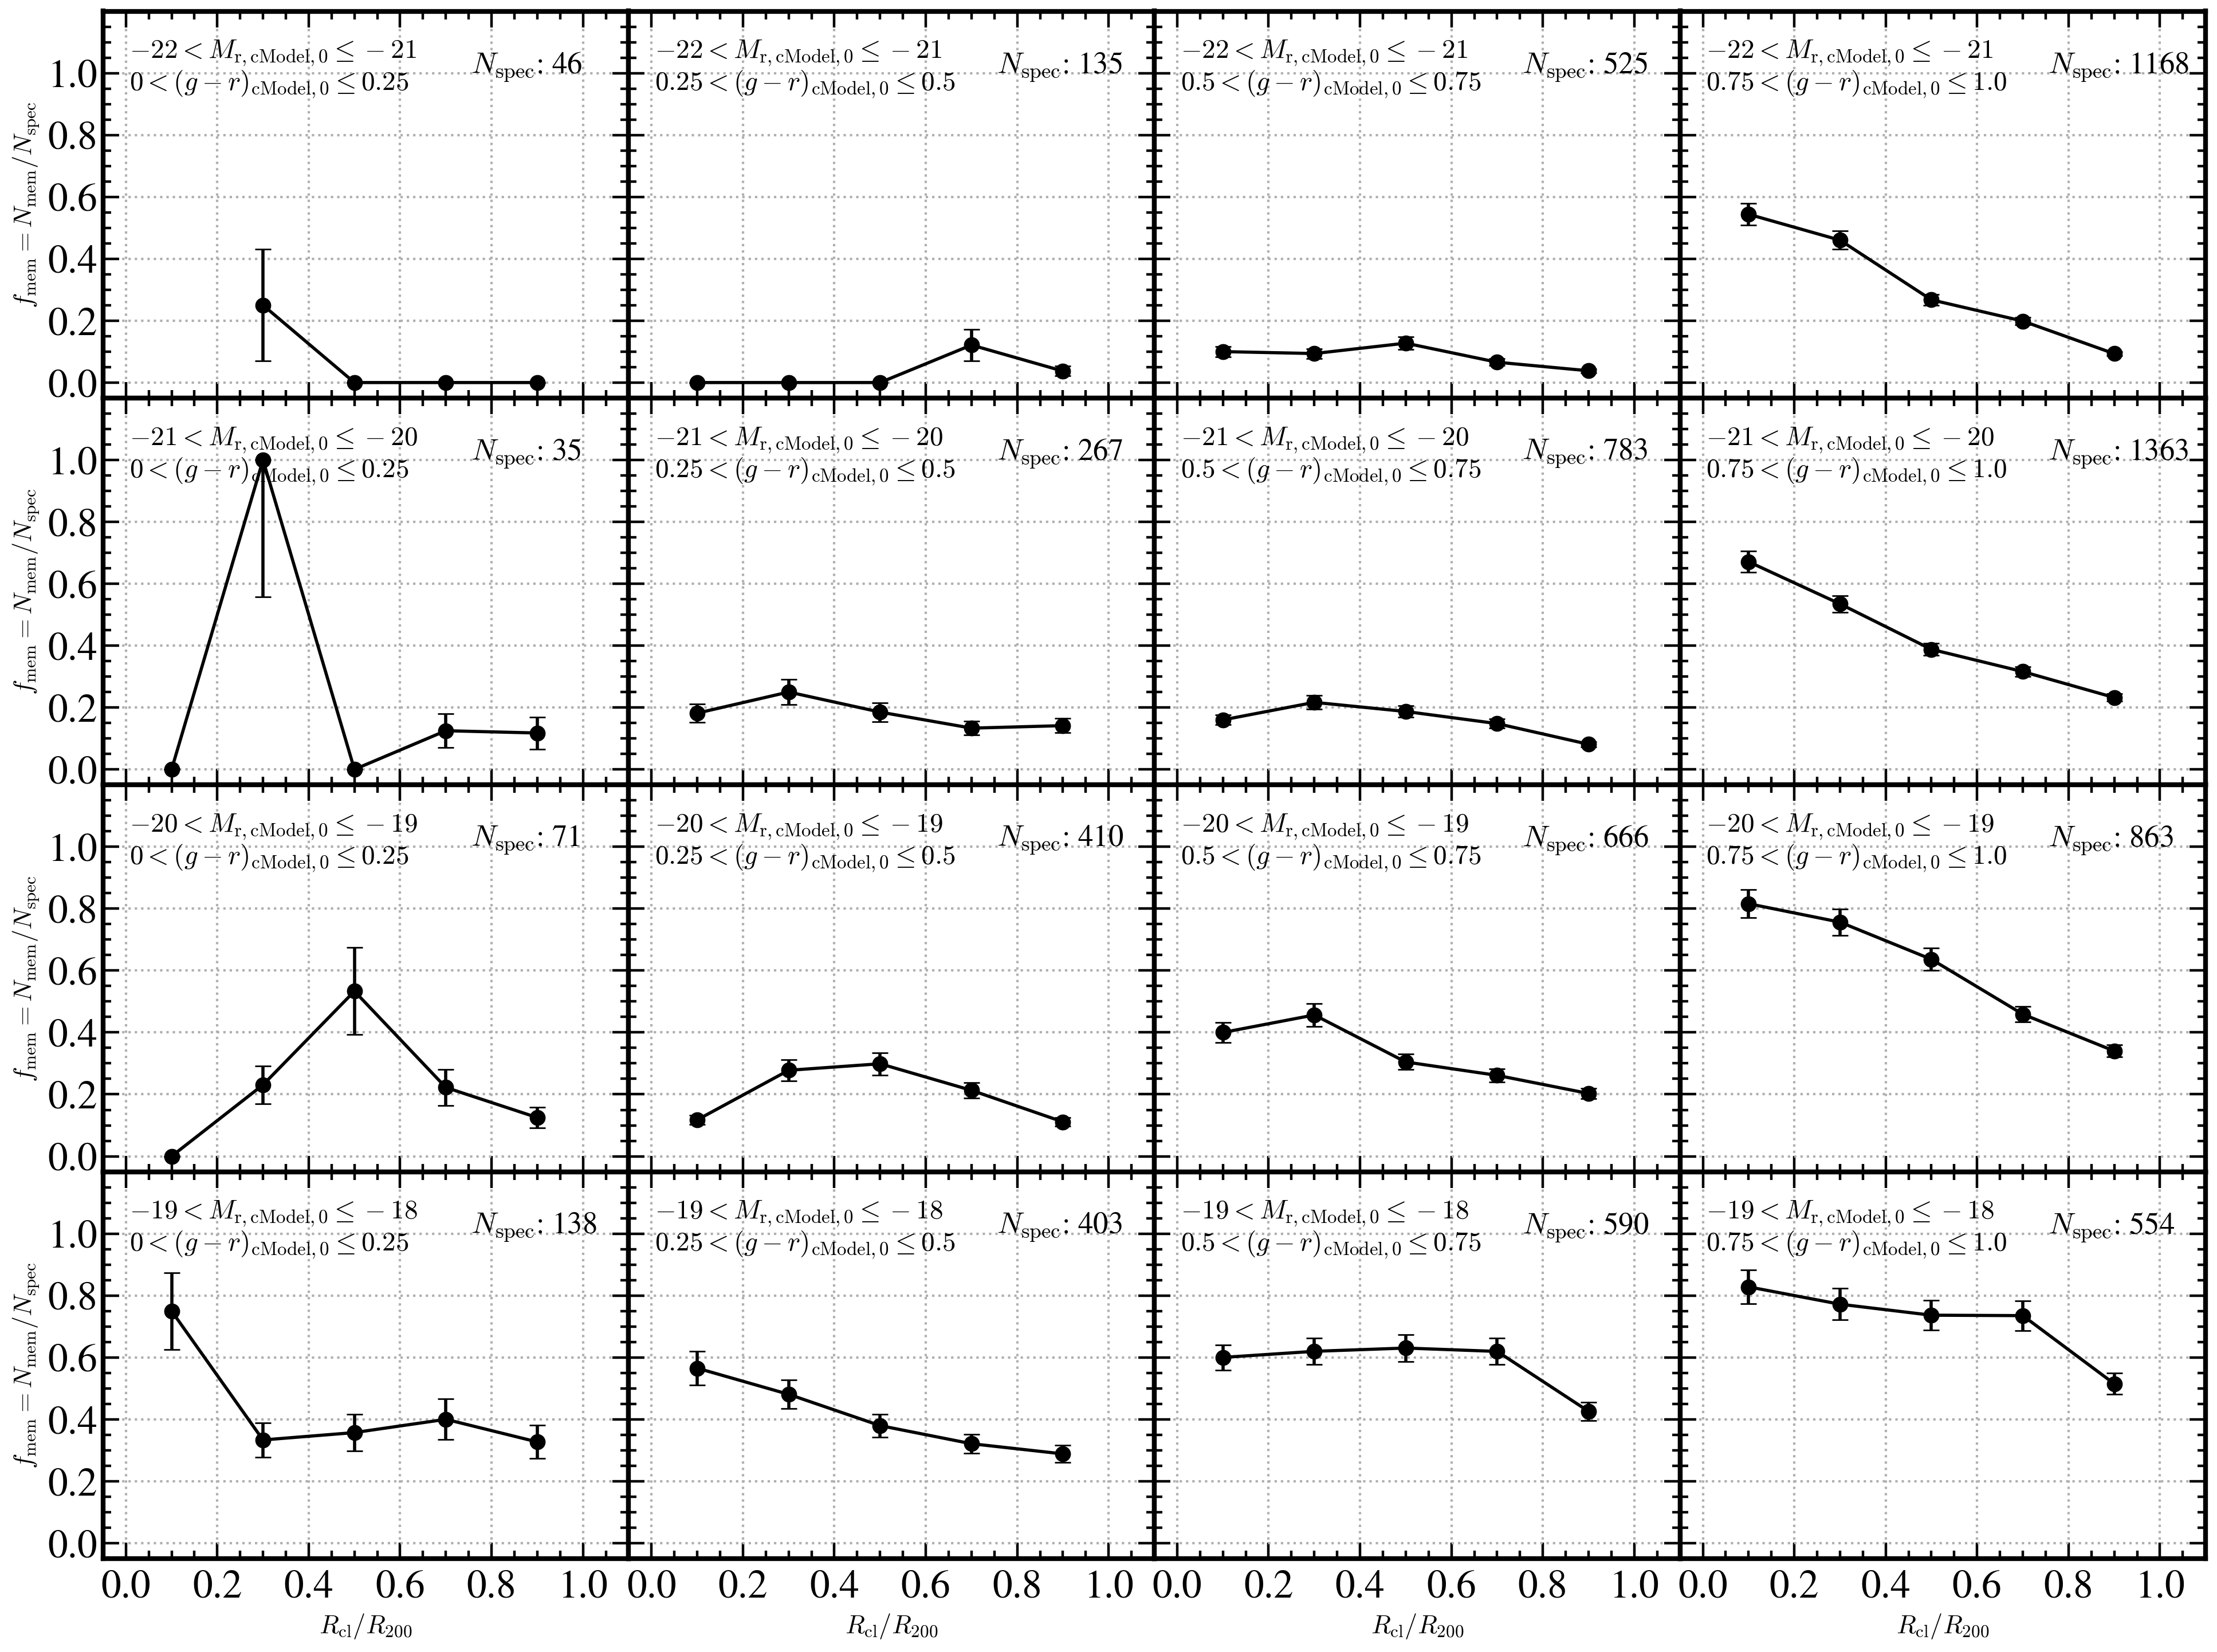

In [4]:
# =============================================================
# 7. Plot f_mem vs Rcl/R200 across Mr and (g-r) bins (Rcl/R200 <= 1.0 only)
# =============================================================

# Subset of bins to display
mr_cuts    = [pd.Interval(-22, -21), pd.Interval(-21, -20),
              pd.Interval(-20, -19), pd.Interval(-19, -18)]
gr_cuts    = [pd.Interval(0, 0.25),  pd.Interval(0.25, 0.5),
              pd.Interval(0.5, 0.75), pd.Interval(0.75, 1.0)]

fig, axes = plt.subplots(
    nrows=len(mr_cuts), ncols=len(gr_cuts),
    figsize=(20, 15),
    gridspec_kw={"wspace": 0, "hspace": 0},
)

for i, mr_bin in enumerate(mr_cuts):
    for j, color_bin in enumerate(gr_cuts):
        ax = axes[i][j]

        # ── f_mem vs Rcl/R200 for this (Mr, g-r) slice, Rcl_bin midpoint <= 1.0 only
        slice_mask = (f_mem_df["Mr_bin"] == mr_bin) & (f_mem_df["color_bin"] == color_bin)
        tdf = f_mem_df[slice_mask].copy()
        # Only keep bins with Rcl_bin midpoint <= 1.0
        if (not tdf.empty) and ("Rcl_bin" in tdf.columns):
            tdf = tdf[tdf["Rcl_bin"].apply(lambda x: x.mid <= 1.0)]

        # ── N_spec and N_mem counts from df_correction, Rcl_bin midpoint <= 1.0 only
        # We'll count ONLY galaxies in bins with Rcl/R200 <= 1.0
        count_mask = (
            (df_correction["Mr_bin"] == mr_bin) &
            (df_correction["color_bin"] == color_bin) &
            (df_correction["Rcl/R200"] <= 1.0)
        )
        n_spec = (df_correction.loc[count_mask, "Z_TOT_Z"] != -99.0).sum()
        n_mem  = (
            (df_correction.loc[count_mask, "Z_TOT_Z"] != -99.0) &
            (df_correction.loc[count_mask, "MEMBER"] == "Y")
        ).sum()

        # ── Poisson-like error bars ───────────────────────────────────
        if (tdf.empty) or n_mem == 0 or n_spec == 0:
            tdf["f_mem_err"] = 0.0
        else:
            tdf["f_mem_err"] = tdf["f_mem"] * np.sqrt(1 / n_mem + 1 / n_spec)

        tdf["f_mem_upper"] = np.minimum(1.0, tdf["f_mem"] + tdf["f_mem_err"])
        tdf["f_mem_lower"] = np.maximum(0.0, tdf["f_mem"] - tdf["f_mem_err"])

        # ── Plot ─────────────────────────────────────────────────────
        if not tdf.empty and "Rcl_bin" in tdf.columns:
            tdf = tdf.sort_values("Rcl_bin")
            midpoints = tdf["Rcl_bin"].apply(lambda x: x.mid).astype(float)
            ax.errorbar(
                midpoints,
                tdf["f_mem"],
                yerr=[tdf["f_mem"] - tdf["f_mem_lower"],
                      tdf["f_mem_upper"] - tdf["f_mem"]],
                fmt="o-",
                color="black",
                capsize=5,
                ms=9,
            )

        # ── Axes style ───────────────────────────────────────────────
        ax.set_xlim(-0.05, 1.1)
        ax.set_ylim(-0.05, 1.2)
        ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.minorticks_on()
        ax.tick_params(axis="both", which="major", length=10)
        ax.tick_params(axis="both", which="minor", length=5)
        ax.xaxis.set_ticks_position("both")
        ax.yaxis.set_ticks_position("both")
        ax.grid(visible=True, which="major", linestyle=":", linewidth=1.5)

        for spine in ax.spines.values():
            spine.set_linewidth(3)

        # ── Tick labels (suppress inner edges) ───────────────────────
        if i < len(mr_cuts) - 1:
            ax.xaxis.set_ticklabels([])
        if j > 0:
            ax.yaxis.set_ticklabels([])
        if i == len(mr_cuts) - 1:
            ax.set_xlabel(r"$R_\mathrm{cl}/R_{200}$", fontsize=16)
        if j == 0:
            ax.set_ylabel(r"$f_\mathrm{mem}=N_\mathrm{mem}/N_\mathrm{spec}$", fontsize=16)

        # ── Panel annotations ─────────────────────────────────────────
        ax.text(
            0.05, 0.93,
            rf"${mr_bin.left}<M_\mathrm{{r,cModel,0}}\leq{mr_bin.right}$",
            fontsize=17, transform=ax.transAxes, va="top",
        )
        ax.text(
            0.05, 0.85,
            rf"${color_bin.left}<(g-r)_\mathrm{{cModel,0}}\leq{color_bin.right}$",
            fontsize=17, transform=ax.transAxes, va="top",
        )
        # N_spec from galaxies with Rcl/R200 <= 1.0 only
        ax.text(
            0.70, 0.90,
            rf"$N_\mathrm{{spec}}$: {n_spec}",
            fontsize=19, transform=ax.transAxes, va="top",
        )

plt.tight_layout()
plt.savefig(f"{MAINPATH}/FIGURE/IMAGES/Figure9.pdf", format="pdf", bbox_inches="tight")
plt.show()